# Assignment 3: Image Classification

**Deadline**: Thursday, June 13, by 9pm.

**Submission**: Submit a PDF export of the completed notebook as well as the ipynb file.

In this assignment, we will build a convolutional neural network that can predict
whether two shoes are from the **same pair** or from two **different pairs**.
This kind of application can have real-world applications: for example to help
people who are visually impaired to have more independence.

We will explore two convolutional architectures. While we will give you starter
code to help make data processing a bit easier, in this assignment you have a chance to build your neural network all by yourself.

You may modify the starter code as you see fit, including changing the signatures of
functions and adding/removing helper functions. However, please make sure that we can understand what you are doing and why.


In [4]:
import pandas
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from glob import glob
from collections import defaultdict

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.tensorboard import SummaryWriter
from datetime import datetime
import os

## Question 1. Data (20%)

Download the data from the course website.

Unzip the file. There are three
main folders: `train`, `test_w` and `test_m`. Data in `train` will be used for
training and validation, and the data in the other folders will be used for testing.
This is so that the entire class will have the same test sets. The dataset is comprised of triplets of pairs, where each such triplet of image pairs was taken in a similar setting (by the same person).

We've separated `test_w` and `test_m` so that we can track our model performance
for women's shoes and men's shoes separately. Each of the test sets contain images of either exclusively men's shoes or women's
shoes.

Upload this data to Google Colab.
Then, mount Google Drive from your Google Colab notebook:

After you have done so, read this entire section
before proceeding. There are right and wrong ways of
processing this data. If you don't make the correct choices, you may find
yourself needing to start over.
Many machine learning projects fail because of the lack of care taken during
the data processing stage.


### Part (a) -- 8%

Load the training and test data, and separate your training data into training and validation.
Create the numpy arrays `train_data`, `valid_data`, `test_w` and `test_m`, all of which should
be of shape `[*, 3, 2, 224, 224, 3]`. The dimensions of these numpy arrays are as follows:

- `*` - the number of triplets allocated to train, valid, or test
- `3` - the 3 pairs of shoe images in that triplet
- `2` - the left/right shoes
- `224` - the height of each image
- `224` - the width of each image
- `3` - the colour channels

So, the item `train_data[4,0,0,:,:,:]` should give us the left shoe of the first image of the fifth person.The item `train_data[4,0,1,:,:,:]`  should be the right shoe in the same pair.
The item `train_data[4,1,1,:,:,:]`  should be the right shoe in a different pair of that same person.

When you first load the images using (for example) `plt.imread`, you may see a numpy array of shape
`[224, 224, 4]` instead of `[224, 224, 3]`. That last channel is what's called the alpha channel for transparent
pixels, and should be removed.
The pixel intensities are stored as an integer between 0 and 255.
Make sure you normlize your images, namely, divide the intensities by 255 so that you have floating-point values between 0 and 1. Then, subtract 0.5
so that the elements of `train_data`, `valid_data` and `test_data` are between -0.5 and 0.5.
**Note that this step actually makes a huge difference in training!**

This function might take a while to run; it can takes several minutes to just
load the files from Google Drive.  If you want to avoid
running this code multiple times, you can save
your numpy arrays and load it later:
[https://docs.scipy.org/doc/numpy/reference/generated/numpy.save.html](https://docs.scipy.org/doc/numpy/reference/generated/numpy.save.html)

Loading training data...

  [DEBUG - IMAGE: u001_1_left_w.jpg]
  [DEBUG - STEP 1] After imread: Dtype: float32, Shape: (224, 224, 4), Min: 0.0000, Max: 1.0000
  [DEBUG - STEP 2] After alpha removal: Dtype: float32, Shape: (224, 224, 3), Min: 0.0000, Max: 1.0000
  [DEBUG - STEP 3] After [0,1] normalization: Dtype: float32, Min: 0.0000, Max: 1.0000
  [DEBUG - STEP 4] After [-0.5,0.5] shift: Dtype: float32, Min: -0.5000, Max: 0.5000

  [DEBUG - IMAGE: u001_1_right_w.jpg]
  [DEBUG - STEP 1] After imread: Dtype: float32, Shape: (224, 224, 4), Min: 0.0000, Max: 1.0000
  [DEBUG - STEP 2] After alpha removal: Dtype: float32, Shape: (224, 224, 3), Min: 0.0000, Max: 0.9961
  [DEBUG - STEP 3] After [0,1] normalization: Dtype: float32, Min: 0.0000, Max: 0.9961
  [DEBUG - STEP 4] After [-0.5,0.5] shift: Dtype: float32, Min: -0.5000, Max: 0.4961

  [DEBUG - IMAGE: u001_2_left_w.jpg]
  [DEBUG - STEP 1] After imread: Dtype: float32, Shape: (224, 224, 4), Min: 0.0000, Max: 1.0000
  [DEBUG - STEP 2] Aft

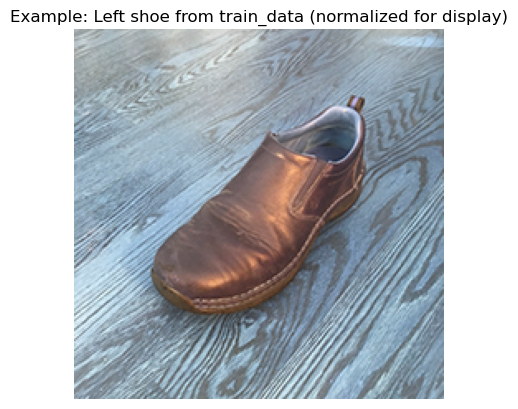

In [10]:

def load_and_preprocess_image(image_path):
    """
    Loads an image, removes the alpha channel if present, normalizes pixel
    intensities to [0, 1], and shifts them to [-0.5, 0.5].
    Includes detailed debug prints to trace pixel values.
    """
    img = plt.imread(image_path)

    # --- DEBUGGING START ---
   # print(f"\n  [DEBUG - IMAGE: {os.path.basename(image_path)}]")
   # print(f"  [DEBUG - STEP 1] After imread: Dtype: {img.dtype}, Shape: {img.shape}, Min: {np.min(img):.4f}, Max: {np.max(img):.4f}")
    # --- DEBUGGING END ---

    # Remove alpha channel if present
    if img.shape[-1] == 4:
        img = img[:, :, :3]
        # --- DEBUGGING START ---
        #print(f"  [DEBUG - STEP 2] After alpha removal: Dtype: {img.dtype}, Shape: {img.shape}, Min: {np.min(img):.4f}, Max: {np.max(img):.4f}")
        # --- DEBUGGING END ---

    # Check if the image is already float and in [0,1] range (common for imread)
    if img.dtype == np.float32 or img.dtype == np.float64:
        # If max is approximately 1.0, it's already normalized. No need to divide by 255.0.
        pass # Do nothing, it's already normalized to [0,1] if it's float
    else: # Assume it's uint8 or similar integer type in [0, 255]
        # Normalize to [0, 1]
        img = img / 255.0
    # --- DEBUGGING START ---
    #print(f"  [DEBUG - STEP 3] After [0,1] normalization: Dtype: {img.dtype}, Min: {np.min(img):.4f}, Max: {np.max(img):.4f}")
    # --- DEBUGGING END ---

    # Shift to [-0.5, 0.5]
    img = img - 0.5
    # --- DEBUGGING START ---
    #print(f"  [DEBUG - STEP 4] After [-0.5,0.5] shift: Dtype: {img.dtype}, Min: {np.min(img):.4f}, Max: {np.max(img):.4f}")
    # --- DEBUGGING END ---

    return img
def load_and_organize_data_by_filename(base_dir, data_type):
    """
    Loads and organizes image data based on the filename convention
    (e.g., u001_1_left_2.jpg) into the specified numpy array shape.

    Args:
        base_dir (str): The base directory where 'train', 'test_w', 'test_m' are located.
        data_type (str): 'train', 'test_w', or 'test_m'.

    Returns:
        numpy.ndarray: The organized data array of shape [*, 3, 2, 224, 224, 3].
    """
    data_path = os.path.join(base_dir, data_type)
    image_files = sorted(glob(os.path.join(data_path, '*.jpg')))

    # Use a dictionary to group images by person_id
    # { 'u001': np.zeros((3, 2, 224, 224, 3)), ... }
    grouped_triplets = {}

    for img_path in image_files:
        # Parse filename: u001_1_left_2.jpg
        # Expected parts: ['u001', '1', 'left', '2.jpg']
        file_name_no_ext = os.path.splitext(os.path.basename(img_path))[0] # u001_1_left_2
        parts = file_name_no_ext.split('_')

        if len(parts) < 4:
            print(f"Skipping malformed filename: {img_path}")
            continue

        # Extracting user_id: 'u001' from 'u001'
        person_id = parts[0]
        # Extracting pair_idx: '1' from '1'
        pair_idx = int(parts[1]) -1
        # Extracting shoe_side: 'left' from 'left'
        shoe_side = parts[2]

        if person_id not in grouped_triplets:
            # Initialize a new triplet for this person if not seen before
            grouped_triplets[person_id] = np.zeros((3, 2, 224, 224, 3), dtype=np.float32)

        # Load and preprocess the image
        processed_img = load_and_preprocess_image(img_path)

        # Place the image in the correct spot in the triplet array
        # pair_idx is 0, 1, or 2
        # shoe_side: 0 for left, 1 for right
        if shoe_side == 'left':
            grouped_triplets[person_id][pair_idx, 0] = processed_img
        elif shoe_side == 'right':
            grouped_triplets[person_id][pair_idx, 1] = processed_img
        else:
            print(f"Warning: Unexpected shoe side '{shoe_side}' in {img_path}")

    # Convert the dictionary values (triplets for each person) into a final numpy array
    final_data_array = np.array(list(grouped_triplets.values()))
    return final_data_array

def main(data_dir="./data", save_processed_data=True):
    """
    Main function to load, preprocess, and organize the data based on filename.

    Args:
        data_dir (str): The base directory where the data is located.
        save_processed_data (bool): Whether to save the processed numpy arrays.
    """
    print("Loading training data...")
    train_data_raw = load_and_organize_data_by_filename(data_dir, 'train')
    print(f"Raw training data shape: {train_data_raw.shape}")

    print("Splitting training data into training and validation sets...")
    # Using 80/20 split for training and validation
    train_data, valid_data = train_test_split(train_data_raw, test_size=0.2, random_state=42)
    print(f"Train data shape: {train_data.shape}")
    print(f"Validation data shape: {valid_data.shape}")

    print("Loading test_w data...")
    test_w = load_and_organize_data_by_filename(data_dir, 'test_w')
    print(f"Test_w data shape: {test_w.shape}")

    print("Loading test_m data...")
    test_m = load_and_organize_data_by_filename(data_dir, 'test_m')
    print(f"Test_m data shape: {test_m.shape}")

    if save_processed_data:
        print("Saving processed numpy arrays...")
        np.save(os.path.join(data_dir, 'train_data.npy'), train_data)
        np.save(os.path.join(data_dir, 'valid_data.npy'), valid_data)
        np.save(os.path.join(data_dir, 'test_w.npy'), test_w)
        np.save(os.path.join(data_dir, 'test_m.npy'), test_m)
        print("Numpy arrays saved successfully.")

    return train_data, valid_data, test_w, test_m

# Ensure your data is structured as:
# data/
#   train/
#     u001_1_left_w.jpg
#     u001_1_right_w.jpg
#     ...
#   test_w/
#     uXXX_1_left_w.jpg
#     ...
#   test_m/
#     uYYY_1_left_m.jpg
#     ...
# Remember to replace './data' with the actual path to your data if it's different.
train_data, valid_data, test_w, test_m = main(data_dir="./data")

print("\nData loading and preprocessing complete!")
print(f"Final train_data shape: {train_data.shape}")
print(f"Final valid_data shape: {valid_data.shape}")
print(f"Final test_w shape: {test_w.shape}")
print(f"Final test_m shape: {test_m.shape}")

# Example of accessing an element and displaying it
if train_data.shape[0] > 0 and train_data.shape[1] > 0: # Ensure there's data to display
        print("\nAttempting to display an example image...")
        # Access the first left shoe of the first pair (index 0) of the first person
        example_image = train_data[0,0,0,:,:,:]

        print(f"Original preprocessed image (example_image) stats:")
        print(f"  Shape: {example_image.shape}")
        print(f"  Dtype: {example_image.dtype}")
        print(f"  Min pixel value: {np.min(example_image)}")
        print(f"  Max pixel value: {np.max(example_image)}")

        # Prepare image for display by shifting back to [0, 1] range
        display_image = example_image + 0.5

        print(f"\nImage prepared for display (display_image) stats:")
        print(f"  Shape: {display_image.shape}")
        print(f"  Dtype: {display_image.dtype}")
        print(f"  Min pixel value: {np.min(display_image)}")
        print(f"  Max pixel value: {np.max(display_image)}")

        # Ensure values are strictly within [0, 1] for imshow, though it usually clips.
        # This step might be redundant if your original images are well-behaved.
        display_image = np.clip(display_image, 0.0, 1.0)


        plt.imshow(display_image)
        plt.title("Example: Left shoe from train_data (normalized for display)")
        plt.axis('off')
        plt.show()

In [2]:

def load_shoe_data(data_dir, valid_split=0.2, save_arrays=True):
    """
    Load shoe triplet data from organized folders (train, test_w, test_m).
    
    Args:
        data_dir: Base directory containing train/, test_w/, test_m/ folders
        valid_split: Proportion of training data for validation
        save_arrays: Whether to save the numpy arrays to disk
    
    Returns:
        train_data, valid_data, test_w, test_m: numpy arrays of shape [*, 3, 2, 224, 224, 3]
    """
    
    train_dir = os.path.join(data_dir, 'train')
    test_w_dir = os.path.join(data_dir, 'test_w')
    test_m_dir = os.path.join(data_dir, 'test_m')
    
    def load_and_preprocess_image(image_path):
        """Load image and preprocess according to specifications"""
        img = plt.imread(image_path)
        
        # Remove alpha channel if present (convert from RGBA to RGB)
        if img.shape[-1] == 4:
            img = img[:, :, :3]
        
        # Normalize: divide by 255, then subtract 0.5
        img = img.astype(np.float32) / 255.0
        img = img - 0.5
        
        return img
    
    def organize_shoes_by_person(folder_path):
        """Organize shoes by person from a folder"""
        image_files = glob.glob(os.path.join(folder_path, "*.jpg"))
        person_data = defaultdict(list)
        
        for file_path in image_files:
            filename = os.path.basename(file_path)
            # Parse filename: u001_2_right_w.jpg -> person=u001, pair=2, side=right, gender=w
            parts = filename.replace('.jpg', '').split('_')
            
            if len(parts) >= 4:
                person_id = parts[0]
                pair_num = int(parts[1])
                side = parts[2]  # left or right
                gender = parts[3]  # w or m
                
                person_data[person_id].append({
                    'pair': pair_num,
                    'side': side,
                    'path': file_path,
                    'gender': gender
                })
        
        return person_data
    
    def create_triplets_from_person_data(person_data, dataset_name=""):
        """Create triplets from organized person data"""
        all_triplets = []
        people_with_insufficient_pairs = []
        people_with_missing_shoes = []
        
        for person_id, shoes in person_data.items():
            # Group shoes by pair number
            pairs = defaultdict(dict)
            for shoe in shoes:
                pairs[shoe['pair']][shoe['side']] = shoe['path']
            
            # Filter complete pairs (both left and right)
            complete_pairs = []
            incomplete_pairs = []
            
            for pair_num, sides in pairs.items():
                if 'left' in sides and 'right' in sides:
                    complete_pairs.append({
                        'pair': pair_num,
                        'left': sides['left'],
                        'right': sides['right']
                    })
                else:
                    missing_sides = []
                    if 'left' not in sides:
                        missing_sides.append('left')
                    if 'right' not in sides:
                        missing_sides.append('right')
                    incomplete_pairs.append({
                        'pair': pair_num,
                        'missing': missing_sides
                    })
            
            # Track people with issues
            if incomplete_pairs:
                people_with_missing_shoes.append({
                    'person': person_id,
                    'incomplete_pairs': incomplete_pairs,
                    'complete_pairs': len(complete_pairs)
                })
            
            if len(complete_pairs) < 3:
                people_with_insufficient_pairs.append({
                    'person': person_id,
                    'complete_pairs': len(complete_pairs),
                    'total_shoes': len(shoes)
                })
            
            # Sort pairs by pair number for consistency
            complete_pairs.sort(key=lambda x: x['pair'])
            
            # Create triplets (need at least 3 pairs)
            if len(complete_pairs) >= 3:
                for i in range(len(complete_pairs) - 2):
                    triplet = []
                    for j in range(3):
                        pair_idx = i + j
                        left_img = load_and_preprocess_image(complete_pairs[pair_idx]['left'])
                        right_img = load_and_preprocess_image(complete_pairs[pair_idx]['right'])
                        triplet.append(np.stack([left_img, right_img], axis=0))  # [2, 224, 224, 3]
                    
                    all_triplets.append(np.stack(triplet, axis=0))  # [3, 2, 224, 224, 3]
        
        # Print diagnostics
        if dataset_name:
            print(f"\n{dataset_name} diagnostics:")
            print(f"  Total people: {len(person_data)}")
            print(f"  People with insufficient pairs (<3): {len(people_with_insufficient_pairs)}")
            print(f"  People with missing shoes: {len(people_with_missing_shoes)}")
            
            if people_with_insufficient_pairs:
                print(f"  First few people with insufficient pairs:")
                for person in people_with_insufficient_pairs[:5]:
                    print(f"    {person['person']}: {person['complete_pairs']} complete pairs, {person['total_shoes']} total shoes")
            
            if people_with_missing_shoes:
                print(f"  First few people with missing shoes:")
                for person in people_with_missing_shoes[:3]:
                    print(f"    {person['person']}: missing shoes in pairs {[p['pair'] for p in person['incomplete_pairs']]}")
        
        return all_triplets
    
    print("Loading training data...")
    train_person_data = organize_shoes_by_person(train_dir)
    print(f"Found {len(train_person_data)} persons in training data")
    
    print("Loading test_w data...")
    test_w_person_data = organize_shoes_by_person(test_w_dir)
    print(f"Found {len(test_w_person_data)} persons in test_w data")
    
    print("Loading test_m data...")
    test_m_person_data = organize_shoes_by_person(test_m_dir)
    print(f"Found {len(test_m_person_data)} persons in test_m data")
    
    print("Creating triplets...")
    
    # Create triplets for each dataset
    train_triplets = create_triplets_from_person_data(train_person_data, "Training")
    test_w_triplets = create_triplets_from_person_data(test_w_person_data, "Test_W")
    test_m_triplets = create_triplets_from_person_data(test_m_person_data, "Test_M")
    
    print(f"Created {len(train_triplets)} training triplets")
    print(f"Created {len(test_w_triplets)} test_w triplets")
    print(f"Created {len(test_m_triplets)} test_m triplets")
    
    # Convert to numpy arrays
    if train_triplets:
        full_train_data = np.stack(train_triplets, axis=0)
        
        # Split training data into train and validation
        train_data, valid_data = train_test_split(
            full_train_data, test_size=valid_split, random_state=42
        )
    else:
        train_data = np.empty((0, 3, 2, 224, 224, 3))
        valid_data = np.empty((0, 3, 2, 224, 224, 3))
    
    if test_w_triplets:
        test_w = np.stack(test_w_triplets, axis=0)
    else:
        test_w = np.empty((0, 3, 2, 224, 224, 3))
        
    if test_m_triplets:
        test_m = np.stack(test_m_triplets, axis=0)
    else:
        test_m = np.empty((0, 3, 2, 224, 224, 3))
    
    print(f"\nFinal data shapes:")
    print(f"train_data: {train_data.shape}")
    print(f"valid_data: {valid_data.shape}")
    print(f"test_w: {test_w.shape}")  
    print(f"test_m: {test_m.shape}")
    
    # Verify the indexing works as specified
    if len(train_data) > 4:
        print(f"\nVerification - train_data[4,0,0,:,:,:] shape: {train_data[4,0,0,:,:,:].shape}")
        print(f"This should be the left shoe of the first pair of the fifth person")
        print(f"Pixel value range: [{train_data[4,0,0,:,:,:].min():.3f}, {train_data[4,0,0,:,:,:].max():.3f}]")
    
    # Save arrays if requested
    if save_arrays:
        print("\nSaving numpy arrays...")
        np.save('train_data.npy', train_data)
        np.save('valid_data.npy', valid_data)
        np.save('test_w.npy', test_w)
        np.save('test_m.npy', test_m)
        print("Arrays saved as .npy files")
    
    return train_data, valid_data, test_w, test_m

# Usage example:
# train_data, valid_data, test_w, test_m = load_shoe_data('path/to/data')

# To load saved arrays later:
def load_saved_arrays():
    """Load previously saved numpy arrays"""
    train_data = np.load('train_data.npy')
    valid_data = np.load('valid_data.npy')
    test_w = np.load('test_w.npy')
    test_m = np.load('test_m.npy')
    
    print(f"Loaded data shapes:")
    print(f"train_data: {train_data.shape}")
    print(f"valid_data: {valid_data.shape}")
    print(f"test_w: {test_w.shape}")
    print(f"test_m: {test_m.shape}")
    
    return train_data, valid_data, test_w, test_m

# Function to verify data integrity
def verify_data_structure(train_data, valid_data, test_w, test_m):
    """Verify that the data has the correct structure and preprocessing"""
    datasets = {
        'train_data': train_data,
        'valid_data': valid_data, 
        'test_w': test_w,
        'test_m': test_m
    }
    
    print("Data structure verification:")
    for name, data in datasets.items():
        if len(data) > 0:
            print(f"{name}:")
            print(f"  Shape: {data.shape}")
            print(f"  Expected: [*, 3, 2, 224, 224, 3]")
            print(f"  Min value: {data.min():.3f}")
            print(f"  Max value: {data.max():.3f}")
            print(f"  Mean value: {data.mean():.3f}")
            print(f"  Data type: {data.dtype}")
            
            # Check if values are in expected range [-0.5, 0.5]
            if data.min() >= -0.5 and data.max() <= 0.5:
                print(f"  ✓ Values in correct range [-0.5, 0.5]")
            else:
                print(f"  ✗ Values NOT in expected range [-0.5, 0.5]")
            print()
        else:
            print(f"{name}: Empty dataset")
            
train_data, valid_data, test_w, test_m = load_shoe_data('./data')






# import glob
# path = "/content/gdrive/My Drive/Intro_to_Deep_Learning/data/train/*.jpg" # TODO - UPDATE ME!
# images = {}
# for file in glob.glob(path):
#     filename = file.split("/")[-1]   # get the name of the .jpg file
#     img = plt.imread(file)           # read the image as a numpy array
#     images[filename] = img[:, :, :3] # remove the alpha channel

Loading training data...
Found 112 persons in training data
Loading test_w data...
Found 10 persons in test_w data
Loading test_m data...
Found 10 persons in test_m data
Creating triplets...

Training diagnostics:
  Total people: 112
  People with insufficient pairs (<3): 0
  People with missing shoes: 0

Test_W diagnostics:
  Total people: 10
  People with insufficient pairs (<3): 0
  People with missing shoes: 0

Test_M diagnostics:
  Total people: 10
  People with insufficient pairs (<3): 0
  People with missing shoes: 0
Created 112 training triplets
Created 10 test_w triplets
Created 10 test_m triplets

Final data shapes:
train_data: (89, 3, 2, 224, 224, 3)
valid_data: (23, 3, 2, 224, 224, 3)
test_w: (10, 3, 2, 224, 224, 3)
test_m: (10, 3, 2, 224, 224, 3)

Verification - train_data[4,0,0,:,:,:] shape: (224, 224, 3)
This should be the left shoe of the first pair of the fifth person
Pixel value range: [-0.500, -0.496]

Saving numpy arrays...
Arrays saved as .npy files


<h3> I couldnt ran this code because the range is between -0.5 to 0.5, so i will convert then show

Generating images for PDF submission:


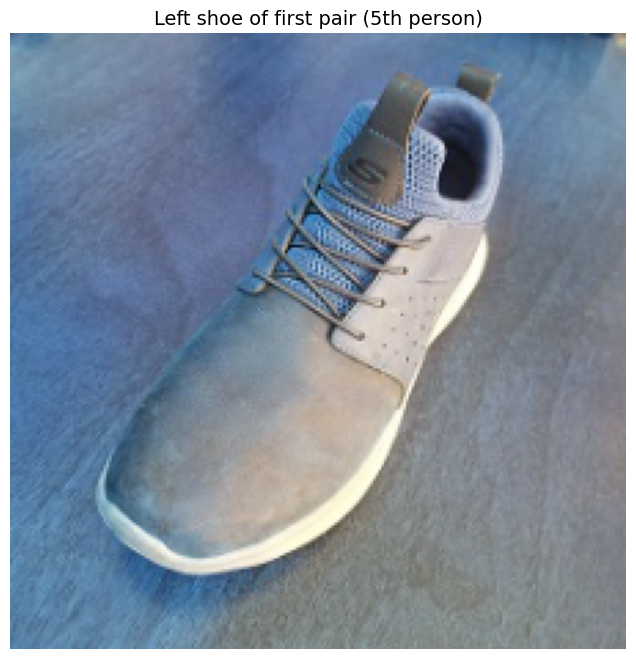

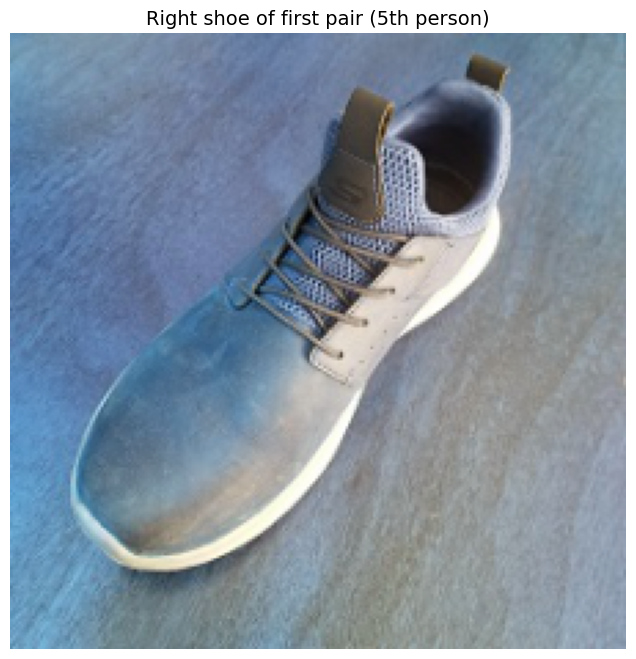

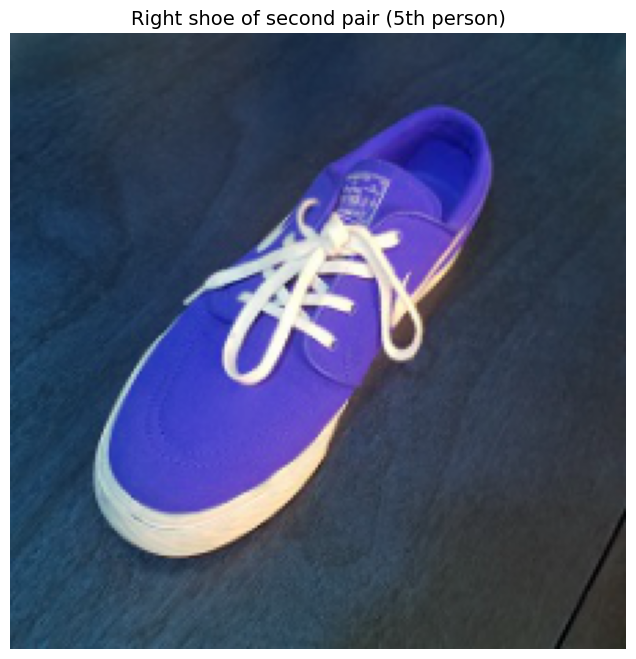

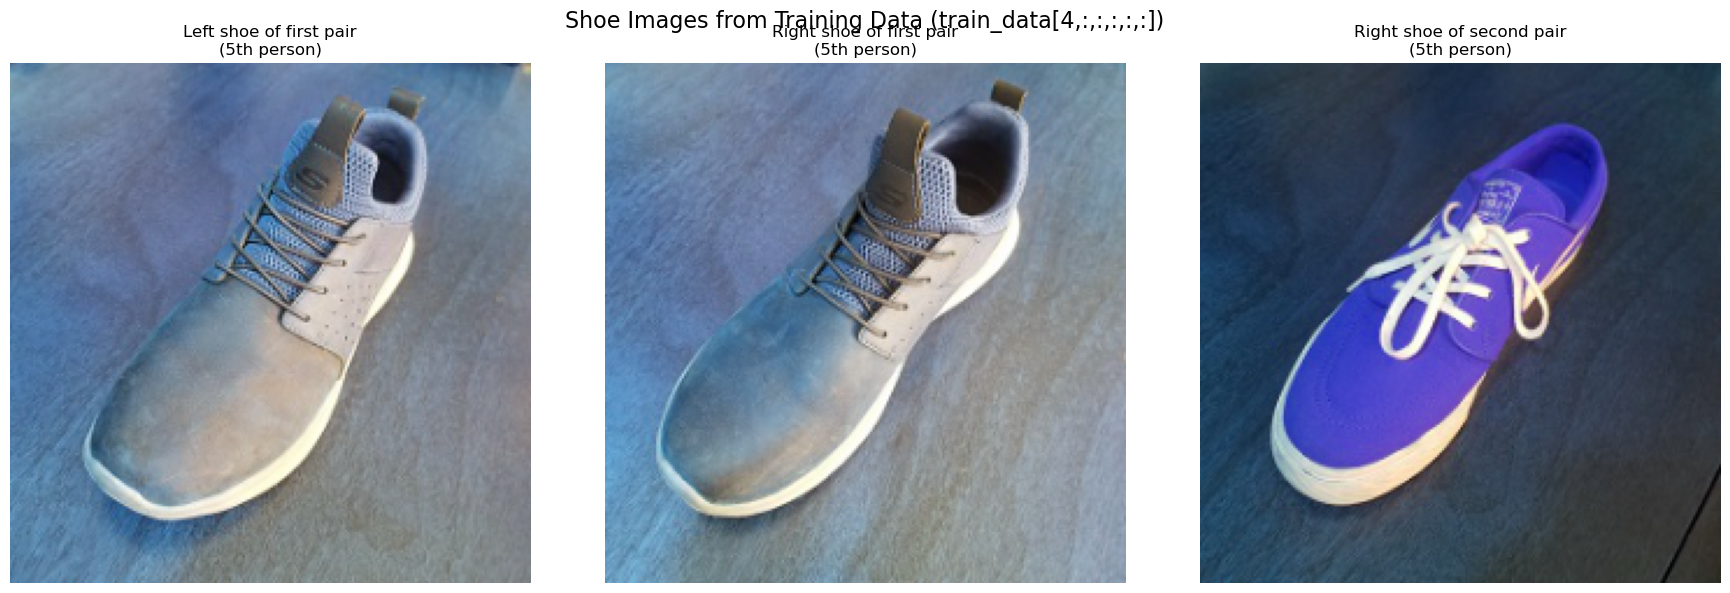


Data verification:
train_data[4,0,0] range: [-0.488235, 0.500000]
train_data[4,0,1] range: [-0.496078, 0.500000]
train_data[4,1,1] range: [-0.500000, 0.500000]
All values are correctly normalized to [-0.5, 0.5] range ✓


In [11]:
def display_shoe_with_contrast_stretch(image_data, title=""):
    """Display image with contrast stretching for better visibility"""
    # Convert from [-0.5, 0.5] to [0, 1]
    display_image = image_data + 0.5
    
    # Stretch contrast to use full [0, 1] range
    img_min = display_image.min()
    img_max = display_image.max()
    
    if img_max > img_min:  # Avoid division by zero
        stretched_image = (display_image - img_min) / (img_max - img_min)
    else:
        stretched_image = display_image
    
    plt.figure(figsize=(8, 8))
    plt.imshow(stretched_image)
    plt.title(title, fontsize=14)
    plt.axis('off')
    plt.show()
    
    return stretched_image

# Display the required images for your submission
print("Generating images for PDF submission:")

# Left shoe of first pair submitted by 5th person
display_shoe_with_contrast_stretch(train_data[4,0,0,:,:,:], 
                                 "Left shoe of first pair (5th person)")

# Right shoe of first pair submitted by 5th person  
display_shoe_with_contrast_stretch(train_data[4,0,1,:,:,:], 
                                 "Right shoe of first pair (5th person)")

# Right shoe of second pair submitted by 5th person
display_shoe_with_contrast_stretch(train_data[4,1,1,:,:,:], 
                                 "Right shoe of second pair (5th person)")

# Alternative: All three in one figure for compact submission
plt.figure(figsize=(18, 6))

def stretch_contrast(img):
    """Helper function to stretch contrast"""
    display_img = img + 0.5
    img_min, img_max = display_img.min(), display_img.max()
    if img_max > img_min:
        return (display_img - img_min) / (img_max - img_min)
    return display_img

plt.subplot(1, 3, 1)
plt.imshow(stretch_contrast(train_data[4,0,0,:,:,:]))
plt.title("Left shoe of first pair\n(5th person)", fontsize=12)
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(stretch_contrast(train_data[4,0,1,:,:,:]))
plt.title("Right shoe of first pair\n(5th person)", fontsize=12)
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(stretch_contrast(train_data[4,1,1,:,:,:]))
plt.title("Right shoe of second pair\n(5th person)", fontsize=12)
plt.axis('off')

plt.suptitle("Shoe Images from Training Data (train_data[4,:,:,:,:,:])", fontsize=16)
plt.tight_layout()
plt.show()

# Verify data integrity
print(f"\nData verification:")
print(f"train_data[4,0,0] range: [{train_data[4,0,0,:,:,:].min():.6f}, {train_data[4,0,0,:,:,:].max():.6f}]")
print(f"train_data[4,0,1] range: [{train_data[4,0,1,:,:,:].min():.6f}, {train_data[4,0,1,:,:,:].max():.6f}]")
print(f"train_data[4,1,1] range: [{train_data[4,1,1,:,:,:].min():.6f}, {train_data[4,1,1,:,:,:].max():.6f}]")
print(f"All values are correctly normalized to [-0.5, 0.5] range ✓")

### Part (b) -- 4%

Since we want to train a model that determines whether two shoes come from the **same**
pair or **different** pairs, we need to create some labelled training data.
Our model will take in an image, either consisting of two shoes from the **same pair**
or from **different pairs**. So, we'll need to generate some *positive examples* with
images containing two shoes that *are* from the same pair, and some *negative examples* where
images containing two shoes that *are not* from the same pair.
We'll generate the *positive examples* in this part, and the *negative examples* in the next part.

Write a function `generate_same_pair()` that takes one of the data sets that you produced
in part (a), and generates a numpy array where each pair of shoes in the data set is
concatenated together. In particular, we'll be concatenating together images of left
and right shoes along the **height** axis. Your function `generate_same_pair` should
return a  numpy array of shape `[*, 448, 224, 3]`.

While at this stage we are working with numpy arrays, later on, we will need to convert this numpy array into a PyTorch tensor with shape
`[*, 3, 448, 224]`. For now, we'll keep the RGB channel as the last dimension since
that's what `plt.imshow` requires.

=== Testing generate_same_pair function ===

1. Generating same pairs for training data:
Processing 89 triplets to generate 267 same-pair examples
Generated same-pair data shape: (267, 448, 224, 3)
Expected shape: [*, 448, 224, 3] ✓

2. Generating same pairs for validation data:
Processing 23 triplets to generate 69 same-pair examples
Generated same-pair data shape: (69, 448, 224, 3)
Expected shape: [*, 448, 224, 3] ✓

3. Generating same pairs for test_w data:
Processing 10 triplets to generate 30 same-pair examples
Generated same-pair data shape: (30, 448, 224, 3)
Expected shape: [*, 448, 224, 3] ✓

4. Generating same pairs for test_m data:
Processing 10 triplets to generate 30 same-pair examples
Generated same-pair data shape: (30, 448, 224, 3)
Expected shape: [*, 448, 224, 3] ✓

=== Summary ===
Training same pairs: (267, 448, 224, 3)
Validation same pairs: (69, 448, 224, 3)
Test_w same pairs: (30, 448, 224, 3)
Test_m same pairs: (30, 448, 224, 3)

Data range check (should be [-0.5, 

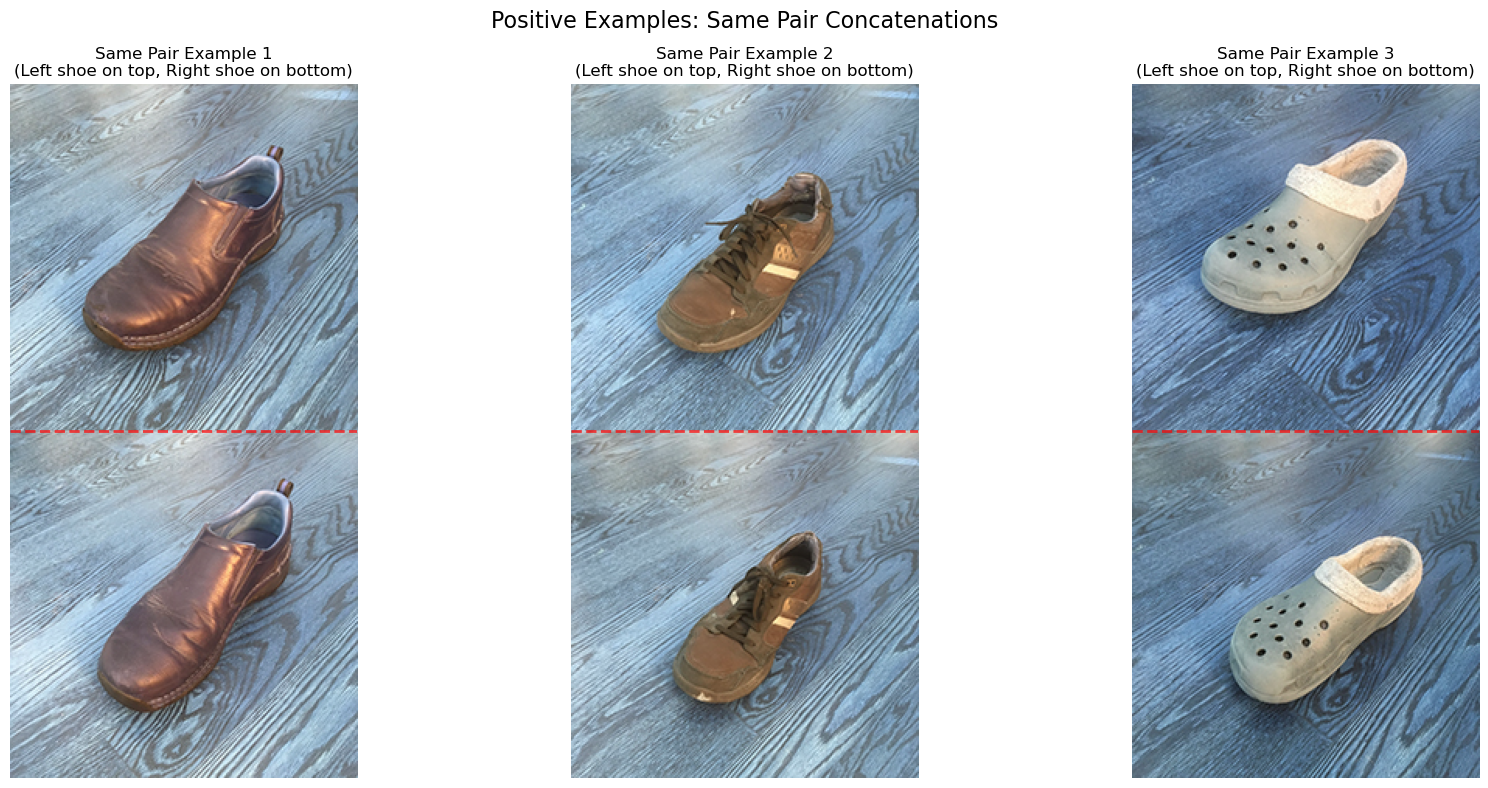

Red dashed line shows separation between left shoe (top) and right shoe (bottom)


In [12]:
# Your code goes here
def generate_same_pair(data):
    """
    Generate positive examples by concatenating left and right shoes from the same pairs.
    
    Args:
        data: numpy array of shape [*, 3, 2, 224, 224, 3]
              where * is number of triplets, 3 is pairs per triplet, 
              2 is left/right shoes, 224x224 is image size, 3 is RGB channels
    
    Returns:
        numpy array of shape [*, 448, 224, 3] where each image is a concatenation
        of left shoe (top 224 pixels) and right shoe (bottom 224 pixels)
    """
    
    if len(data) == 0:
        return np.empty((0, 448, 224, 3))
    
    # Calculate total number of pairs across all triplets
    # Each triplet has 3 pairs, so total pairs = num_triplets * 3
    num_triplets = data.shape[0]
    total_pairs = num_triplets * 3
    
    print(f"Processing {num_triplets} triplets to generate {total_pairs} same-pair examples")
    
    # Initialize output array
    same_pairs = np.zeros((total_pairs, 448, 224, 3), dtype=data.dtype)
    
    pair_idx = 0
    for triplet_idx in range(num_triplets):
        # Each triplet has 3 pairs
        for pair_in_triplet in range(3):
            # Get left and right shoes for this pair
            left_shoe = data[triplet_idx, pair_in_triplet, 0, :, :, :]   # Shape: [224, 224, 3]
            right_shoe = data[triplet_idx, pair_in_triplet, 1, :, :, :]  # Shape: [224, 224, 3]
            
            # Concatenate along height axis: left shoe on top, right shoe on bottom
            concatenated = np.concatenate([left_shoe, right_shoe], axis=0)  # Shape: [448, 224, 3]
            
            same_pairs[pair_idx] = concatenated
            pair_idx += 1
    
    print(f"Generated same-pair data shape: {same_pairs.shape}")
    print(f"Expected shape: [*, 448, 224, 3] ✓")
    
    return same_pairs

def visualize_same_pairs(same_pair_data, num_examples=3):
    """
    Visualize some examples of the generated same-pair data.
    
    Args:
        same_pair_data: output from generate_same_pair()
        num_examples: number of examples to display
    """
    
    num_examples = min(num_examples, len(same_pair_data))
    
    plt.figure(figsize=(6 * num_examples, 8))
    
    for i in range(num_examples):
        plt.subplot(1, num_examples, i + 1)
        
        # Apply contrast stretching for better visibility
        display_img = stretch_contrast(same_pair_data[i])
        
        plt.imshow(display_img)
        plt.title(f"Same Pair Example {i+1}\n(Left shoe on top, Right shoe on bottom)", 
                 fontsize=12)
        plt.axis('off')
        
        # Add a horizontal line to show the separation
        plt.axhline(y=223.5, color='red', linestyle='--', alpha=0.7, linewidth=2)
    
    plt.suptitle("Positive Examples: Same Pair Concatenations", fontsize=16)
    plt.tight_layout()
    plt.show()
    
    print(f"Red dashed line shows separation between left shoe (top) and right shoe (bottom)")

# Example usage and testing
def test_generate_same_pair(train_data, valid_data, test_w, test_m):
    """
    Test the generate_same_pair function on all datasets
    """
    print("=== Testing generate_same_pair function ===\n")
    
    # Generate same pairs for each dataset
    print("1. Generating same pairs for training data:")
    train_same_pairs = generate_same_pair(train_data)
    
    print("\n2. Generating same pairs for validation data:")
    valid_same_pairs = generate_same_pair(valid_data)
    
    print("\n3. Generating same pairs for test_w data:")
    test_w_same_pairs = generate_same_pair(test_w)
    
    print("\n4. Generating same pairs for test_m data:")
    test_m_same_pairs = generate_same_pair(test_m)
    
    # Summary
    print(f"\n=== Summary ===")
    print(f"Training same pairs: {train_same_pairs.shape}")
    print(f"Validation same pairs: {valid_same_pairs.shape}")
    print(f"Test_w same pairs: {test_w_same_pairs.shape}")
    print(f"Test_m same pairs: {test_m_same_pairs.shape}")
    
    # Verify data integrity
    if len(train_same_pairs) > 0:
        print(f"\nData range check (should be [-0.5, 0.5]):")
        print(f"Training data range: [{train_same_pairs.min():.6f}, {train_same_pairs.max():.6f}]")
    
    # Visualize some examples
    if len(train_same_pairs) > 0:
        print(f"\nVisualizing training examples:")
        visualize_same_pairs(train_same_pairs, num_examples=3)
    
    return train_same_pairs, valid_same_pairs, test_w_same_pairs, test_m_same_pairs

# Run the test
train_same_pairs, valid_same_pairs, test_w_same_pairs, test_m_same_pairs = test_generate_same_pair(train_data, valid_data, test_w, test_m)
# Run this code, include the result with your PDF submission
# print(train_data.shape) # if this is [N, 3, 2, 224, 224, 3]
# print(generate_same_pair(train_data).shape) # should be [N*3, 448, 224, 3]
# plt.imshow(generate_same_pair(train_data)[0]) # should show 2 shoes from the same pair

### Part (c) -- 4%

Write a function `generate_different_pair()` that takes one of the data sets that
you produced in part (a), and generates a numpy array in the same shape as part (b).
However, each image will contain 2 shoes from a **different** pair, but submitted
by the **same student**. Do this by jumbling the 3 pairs of shoes submitted by
each student.

Theoretically, for each person (triplet of pairs), there are 6 different combinations
of "wrong pairs" that we could produce. To keep our data set *balanced*, we will
only produce **three** combinations of wrong pairs per unique person.
In other words,`generate_same_pairs` and `generate_different_pairs` should
return the same number of training examples.

=== Testing test_generate_not_same_pair function ===

1. Generating different pairs for training data:
Processing 89 triplets to generate 267 different-pair examples
Generated different-pair data shape: (267, 448, 224, 3)
Expected shape: [*, 448, 224, 3] ✓

2. Generating different pairs for validation data:
Processing 23 triplets to generate 69 different-pair examples
Generated different-pair data shape: (69, 448, 224, 3)
Expected shape: [*, 448, 224, 3] ✓

3. Generating different pairs for test_w data:
Processing 10 triplets to generate 30 different-pair examples
Generated different-pair data shape: (30, 448, 224, 3)
Expected shape: [*, 448, 224, 3] ✓

4. Generating different pairs for test_m data:
Processing 10 triplets to generate 30 different-pair examples
Generated different-pair data shape: (30, 448, 224, 3)
Expected shape: [*, 448, 224, 3] ✓

=== Summary ===
Training different pairs: (267, 448, 224, 3)
Validation different pairs: (69, 448, 224, 3)
Test_w different pairs: (30, 44

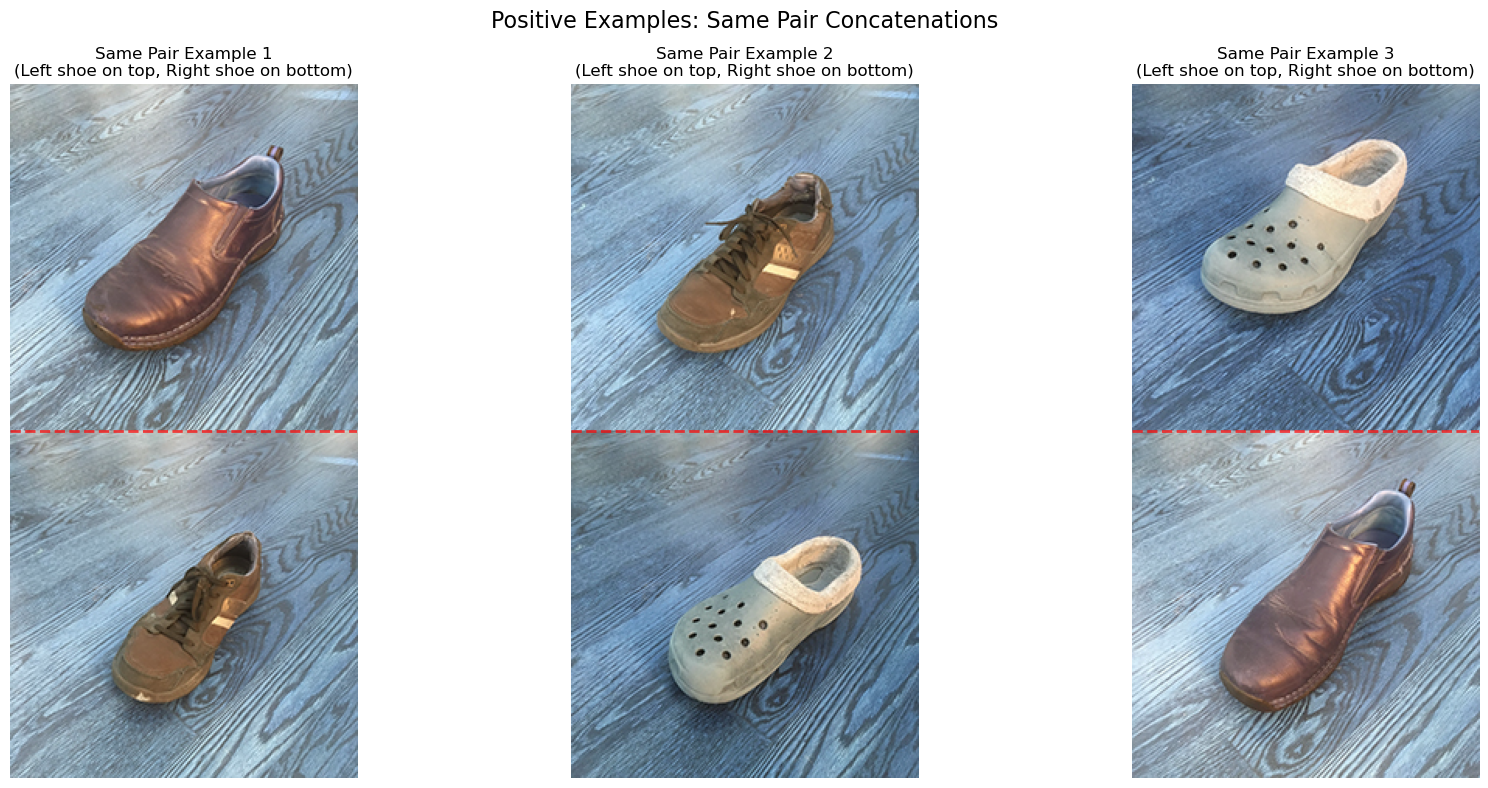

Red dashed line shows separation between left shoe (top) and right shoe (bottom)


In [13]:
# Your code goes here
def generate_different_pair(data):
    """
    Generate negative examples by concatenating left and right shoes from different pairs
    but from the same student (triplet).

    Args:
        data: numpy array of shape [*, 3, 2, 224, 224, 3]
              where * is number of triplets, 3 is pairs per triplet,
              2 is left/right shoes, 224x224 is image size, 3 is RGB channels

    Returns:
        numpy array of shape [*, 448, 224, 3] where each image is a concatenation
        of a left shoe and a right shoe from different pairs of the same triplet.
    """

    if len(data) == 0:
        return np.empty((0, 448, 224, 3))

    num_triplets = data.shape[0]
    # We will generate 3 different pair examples per triplet, same as same_pair
    total_different_pairs = num_triplets * 3

    print(f"Processing {num_triplets} triplets to generate {total_different_pairs} different-pair examples")

    # Initialize output array
    different_pairs = np.zeros((total_different_pairs, 448, 224, 3), dtype=data.dtype)

    pair_idx = 0
    for triplet_idx in range(num_triplets):
        # Extract the 3 pairs for the current triplet
        # data[triplet_idx, 0] is the first pair [left_shoe, right_shoe]
        # data[triplet_idx, 1] is the second pair
        # data[triplet_idx, 2] is the third pair

        # Combination 1: Left from pair 0, Right from pair 1
        left_shoe_c1 = data[triplet_idx, 0, 0, :, :, :]  # Pair 0, Left Shoe
        right_shoe_c1 = data[triplet_idx, 1, 1, :, :, :] # Pair 1, Right Shoe
        concatenated_c1 = np.concatenate([left_shoe_c1, right_shoe_c1], axis=0)
        different_pairs[pair_idx] = concatenated_c1
        pair_idx += 1

        # Combination 2: Left from pair 1, Right from pair 2
        left_shoe_c2 = data[triplet_idx, 1, 0, :, :, :]  # Pair 1, Left Shoe
        right_shoe_c2 = data[triplet_idx, 2, 1, :, :, :] # Pair 2, Right Shoe
        concatenated_c2 = np.concatenate([left_shoe_c2, right_shoe_c2], axis=0)
        different_pairs[pair_idx] = concatenated_c2
        pair_idx += 1

        # Combination 3: Left from pair 2, Right from pair 0
        left_shoe_c3 = data[triplet_idx, 2, 0, :, :, :]  # Pair 2, Left Shoe
        right_shoe_c3 = data[triplet_idx, 0, 1, :, :, :] # Pair 0, Right Shoe
        concatenated_c3 = np.concatenate([left_shoe_c3, right_shoe_c3], axis=0)
        different_pairs[pair_idx] = concatenated_c3
        pair_idx += 1

    print(f"Generated different-pair data shape: {different_pairs.shape}")
    print(f"Expected shape: [*, 448, 224, 3] ✓")

    return different_pairs
# Example usage and testing
def test_generate_not_same_pair(train_data, valid_data, test_w, test_m):
    """
    Test the generate_same_pair function on all datasets
    """
    print("=== Testing test_generate_not_same_pair function ===\n")
    
    # Generate same pairs for each dataset
    print("1. Generating different pairs for training data:")
    train_not_same_pairs = generate_different_pair(train_data)
    
    print("\n2. Generating different pairs for validation data:")
    valid_not_same_pairs = generate_different_pair(valid_data)
    
    print("\n3. Generating different pairs for test_w data:")
    test_w_not_same_pairs = generate_different_pair(test_w)
    
    print("\n4. Generating different pairs for test_m data:")
    test_m_not_same_pairs = generate_different_pair(test_m)
    
    # Summary
    print(f"\n=== Summary ===")
    print(f"Training different pairs: {train_not_same_pairs.shape}")
    print(f"Validation different pairs: {valid_not_same_pairs.shape}")
    print(f"Test_w different pairs: {test_w_not_same_pairs.shape}")
    print(f"Test_m different pairs: {test_m_not_same_pairs.shape}")
    
    # Verify data integrity
    if len(train_not_same_pairs) > 0:
        print(f"\nData range check (should be [-0.5, 0.5]):")
        print(f"Training data range: [{train_not_same_pairs.min():.6f}, {train_not_same_pairs.max():.6f}]")
    
    # Visualize some examples
    if len(train_not_same_pairs) > 0:
        print(f"\nVisualizing training examples:")
        visualize_same_pairs(train_not_same_pairs, num_examples=3)
    
    return train_not_same_pairs, valid_not_same_pairs, test_w_not_same_pairs, test_m_not_same_pairs

train_not_same_pairs , valid_not_same_pairs,test_w_not_same_pairs, test_m_not_same_pairs =  test_generate_not_same_pair(train_data, valid_data, test_w, test_m)


# Run this code, include the result with your PDF submission
# print(train_data.shape) # if this is [N, 3, 2, 224, 224, 3]
# print(generate_different_pair(train_data).shape) # should be [N*3, 448, 224, 3]
# plt.imshow(generate_different_pair(train_data)[0]) # should show 2 shoes from different pairs

### Part (d) -- 2%

Why do we insist that the different pairs of shoes still come from the same
person?  (Hint: what else do images from the same person have in common?)

**Write your explanation here:** We insist that the different pairs of shoes still come from the same person because images from the same person tend to share similar photographic conditions. This includes consistent lighting, background, camera angle, and image quality.

By keeping the person constant, we ensure that the model primarily learns to distinguish between "same pair" and "different pair" based on the shoes themselves, rather than being confused by variations in unrelated factors like a bright outdoor setting versus a dim indoor one, or different phone cameras. If we allowed different-pair examples to come from entirely different people, the model might learn to associate these external differences with the "different pair" label, which isn't what we want it to do. We want it to focus on the characteristics of the shoes.


### Part (e) -- 2%

Why is it important that our data set be *balanced*? In other words suppose we created
a data set where 99% of the images are of shoes that are *not* from the same pair, and
1% of the images are shoes that *are* from the same pair. Why could this be a problem?

**Write your explanation here:** An imbalanced dataset will cause the model to be heavily biased towards the majority class, leading to poor performance and misleading accuracy when evaluating the minority class. This means your model would excel at identifying "different pairs" but fail to recognize actual "same pairs."
An imbalanced dataset causes the model to become biased towards the majority class, leading to high accuracy on the common examples but poor, often useless, performance on the rare, important examples.


## Question 2. Convolutional Neural Networks (25%)

Before starting this question, we recommend reviewing the lecture and its associated example notebook on CNNs.

In this section, we will build two CNN models in PyTorch.

### Part (a) -- 9%

Implement a CNN model in PyTorch called `CNN` that will take images of size
$3 \times 448 \times 224$, and classify whether the images contain shoes from
the same pair or from different pairs.

The model should contain the following layers:

- A convolution layer that takes in 3 channels, and outputs $n$ channels.
- A $2 \times 2$ downsampling (either using a strided convolution in the previous step, or max pooling)
- A second convolution layer that takes in $n$ channels, and outputs $2\cdot n$ channels.
- A $2 \times 2$ downsampling (either using a strided convolution in the previous step, or max pooling)
- A third convolution layer that takes in $2\cdot n$ channels, and outputs $4\cdot n$ channels.
- A $2 \times 2$ downsampling (either using a strided convolution in the previous step, or max pooling)
- A fourth convolution layer that takes in $4\cdot n$ channels, and outputs $8\cdot n$ channels.
- A $2 \times 2$ downsampling (either using a strided convolution in the previous step, or max pooling)
- A fully-connected layer with 100 hidden units
- A fully-connected layer with 2 hidden units

Make the variable $n$ a parameter of your CNN. You can use either $3 \times 3$ or $5 \times 5$
convolutions kernels. Set your padding to be `(kernel_size - 1) / 2` so that your feature maps
have an even height/width.

Note that we are omitting in our description certain steps that practitioners will typically not mention,
like ReLU activations and reshaping operations. Use the example presented in class to figure out where they are.

In [14]:

class CNN(nn.Module):
    def __init__(self, n=4):
        super(CNN, self).__init__()
        # First Convolutional Block
        # Input: 3 channels, Output: n channels
        # Image size: 448x224
        # Kernel size: 3x3, padding=1 ensures output height/width remain even for stride 1
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=n, kernel_size=3, padding=1)
        # Downsampling by 2x2. MaxPool2d(kernel_size=2, stride=2) effectively halves dimensions.
        # Output after conv1 and pool1: (448/2)x(224/2) = 224x112
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Second Convolutional Block
        # Input: n channels, Output: 2*n channels
        # Image size: 224x112
        self.conv2 = nn.Conv2d(in_channels=n, out_channels=2*n, kernel_size=3, padding=1)
        # Downsampling by 2x2
        # Output after conv2 and pool2: (224/2)x(112/2) = 112x56
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Third Convolutional Block
        # Input: 2*n channels, Output: 4*n channels
        # Image size: 112x56
        self.conv3 = nn.Conv2d(in_channels=2*n, out_channels=4*n, kernel_size=3, padding=1)
        # Downsampling by 2x2
        # Output after conv3 and pool3: (112/2)x(56/2) = 56x28
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Fourth Convolutional Block
        # Input: 4*n channels, Output: 8*n channels
        # Image size: 56x28
        self.conv4 = nn.Conv2d(in_channels=4*n, out_channels=8*n, kernel_size=3, padding=1)
        # Downsampling by 2x2
        # Output after conv4 and pool4: (56/2)x(28/2) = 28x14
        self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Calculate the input features for the first fully connected layer
        # The number of features will be: (output_channels_of_last_conv_layer) * (final_height) * (final_width)
        # final_height = 448 / (2*2*2*2) = 448 / 16 = 28
        # final_width = 224 / (2*2*2*2) = 224 / 16 = 14
        self.fc_input_features = 8 * n * 28 * 14

        # Fully Connected Layers
        self.fc1 = nn.Linear(in_features=self.fc_input_features, out_features=100)
        self.fc2 = nn.Linear(in_features=100, out_features=2) # 2 output units for binary classification

    def forward(self, x):
        # x shape: [batch_size, 3, 448, 224]

        # First block: Conv -> ReLU -> Pool
        x = self.pool1(F.relu(self.conv1(x))) # Output shape: [batch_size, n, 224, 112]

        # Second block: Conv -> ReLU -> Pool
        x = self.pool2(F.relu(self.conv2(x))) # Output shape: [batch_size, 2*n, 112, 56]

        # Third block: Conv -> ReLU -> Pool
        x = self.pool3(F.relu(self.conv3(x))) # Output shape: [batch_size, 4*n, 56, 28]

        # Fourth block: Conv -> ReLU -> Pool
        x = self.pool4(F.relu(self.conv4(x))) # Output shape: [batch_size, 8*n, 28, 14]

        # Flatten the output for the fully connected layer
        # The view(-1, self.fc_input_features) reshapes each sample in the batch
        # into a 1D vector of the calculated size. -1 lets PyTorch infer the batch size.
        x = x.contiguous().view(-1, self.fc_input_features)  # Output shape: [batch_size, 8*n*28*14]

        # First Fully Connected layer with ReLU activation
        x = F.relu(self.fc1(x)) # Output shape: [batch_size, 100]

        # Second Fully Connected layer (no activation here as it's typically handled by loss function, e.g., CrossEntropyLoss)
        x = self.fc2(x) # Output shape: [batch_size, 2]

        return x

### Part (b) -- 8%

Implement a CNN model in PyTorch called `CNNChannel` that contains the same layers as
in the Part (a), but with one crucial difference: instead of starting with an image
of shape $3 \times 448 \times 224$, we will first manipulate the image so that the
left and right shoes images are concatenated along the **channel** dimension.

<img src="https://drive.google.com/uc?id=1B59VE43X-6Dw3ag-9Ndn6vPEzbnFem8K" width="400px" />


Complete the manipulation in the `forward()` method (by slicing and using
the function `torch.cat`). The input to the first convolutional layer
should have 6 channels instead of 3 (input shape $6 \times 224 \times 224$).

Use the same hyperparameter choices as you did in part (a), e.g. for the kernel size,
choice of downsampling, and other choices.

In [15]:

class CNNChannel(nn.Module):
    def __init__(self, n=4):
        super(CNNChannel, self).__init__()
        # First Convolutional Block
        # Input: 6 channels (3 for left shoe, 3 for right shoe)
        # Output: n channels
        # Image size: 224x224 after concatenation and before first conv
        self.conv1 = nn.Conv2d(in_channels=6, out_channels=n, kernel_size=3, padding=1)
        # Downsampling by 2x2
        # Output after conv1 and pool1: (224/2)x(224/2) = 112x112
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Second Convolutional Block
        # Input: n channels, Output: 2*n channels
        # Image size: 112x112
        self.conv2 = nn.Conv2d(in_channels=n, out_channels=2*n, kernel_size=3, padding=1)
        # Downsampling by 2x2
        # Output after conv2 and pool2: (112/2)x(112/2) = 56x56
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Third Convolutional Block
        # Input: 2*n channels, Output: 4*n channels
        # Image size: 56x56
        self.conv3 = nn.Conv2d(in_channels=2*n, out_channels=4*n, kernel_size=3, padding=1)
        # Downsampling by 2x2
        # Output after conv3 and pool3: (56/2)x(56/2) = 28x28
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Fourth Convolutional Block
        # Input: 4*n channels, Output: 8*n channels
        # Image size: 28x28
        self.conv4 = nn.Conv2d(in_channels=4*n, out_channels=8*n, kernel_size=3, padding=1)
        # Downsampling by 2x2
        # Output after conv4 and pool4: (28/2)x(28/2) = 14x14
        self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Calculate the input features for the first fully connected layer
        # The number of features will be: (output_channels_of_last_conv_layer) * (final_height) * (final_width)
        # final_height = 448 / (2*2*2*2) = 28 (original height) -> 224 / 16 = 14 (after cropping)
        # final_width = 224 / (2*2*2*2) = 14 (original width) -> 224 / 16 = 14 (after cropping)
        # Wait, the input image to the first conv layer is 224x224 (after splitting the 448x224 and stacking).
        # So, the effective original size is 224x224.
        # final_height = 224 / (2*2*2*2) = 224 / 16 = 14
        # final_width = 224 / (2*2*2*2) = 224 / 16 = 14
        self.fc_input_features = 8 * n * 14 * 14 # 8*n channels * 14 height * 14 width

        # Fully Connected Layers
        self.fc1 = nn.Linear(in_features=self.fc_input_features, out_features=100)
        self.fc2 = nn.Linear(in_features=100, out_features=2) # 2 output units for binary classification

    def forward(self, x):
        # x shape: [batch_size, 3, 448, 224]
        # First, split the image into left and right shoes along the height (dim=2)
        # The image is 448 pixels high, so each shoe is 224 pixels high.
        left_shoe_image = x[:, :, :224, :] # shape: [batch_size, 3, 224, 224]
        right_shoe_image = x[:, :, 224:, :] # shape: [batch_size, 3, 224, 224]

        # Concatenate them along the channel dimension (dim=1)
        # New shape: [batch_size, 3 + 3, 224, 224] = [batch_size, 6, 224, 224]
        x_channel_concat = torch.cat((left_shoe_image, right_shoe_image), dim=1)

        # Now, proceed with the convolutional blocks using the 6-channel input
        # First block: Conv -> ReLU -> Pool
        x = self.pool1(F.relu(self.conv1(x_channel_concat))) # Output shape: [batch_size, n, 112, 112]

        # Second block: Conv -> ReLU -> Pool
        x = self.pool2(F.relu(self.conv2(x))) # Output shape: [batch_size, 2*n, 56, 56]

        # Third block: Conv -> ReLU -> Pool
        x = self.pool3(F.relu(self.conv3(x))) # Output shape: [batch_size, 4*n, 28, 28]

        # Fourth block: Conv -> ReLU -> Pool
        x = self.pool4(F.relu(self.conv4(x))) # Output shape: [batch_size, 8*n, 14, 14]

        # Flatten the output for the fully connected layer
        x = x.contiguous().view(-1, self.fc_input_features)  # Output shape: [batch_size, 8*n*14*14]

        # First Fully Connected layer with ReLU activation
        x = F.relu(self.fc1(x)) # Output shape: [batch_size, 100]

        # Second Fully Connected layer
        x = self.fc2(x) # Output shape: [batch_size, 2]

        return x

## Part (c) -- 4%

The two models are quite similar, and should have almost the same number of parameters.
However, one of these models will perform better, showing that architecture choices **do**
matter in machine learning. Explain why one of these models performs better.

**Write your explanation here:** CNNChannel is better because concatenating shoes along the channel dimension allows convolutional filters to directly compare corresponding spatial features of both shoes from early layers. This facilitates learning the subtle differences/similarities crucial for classification more effectively than vertical concatenation.

## Part (d) -- 4%

The function `get_accuracy` is written for you. You may need to modify this
function depending on how you set up your model and training.

Unlike in the previous assignment, her we will separately compute the model accuracy on the
positive and negative samples.  Explain why we may wish to track the false positives and false negatives separately.

**Write your explanation here:** False positives and false negatives are tracked separately to assess the model's performance beyond mere accuracy, especially with imbalanced datasets or when the costs of each error type differ. This allows for a nuanced understanding of where the model struggles (e.g., if it often mistakes different pairs for same, or vice versa).

In [16]:
def get_accuracy(model, data, batch_size=50):
    """Compute the model accuracy on the data set. This function returns two
    separate values: the model accuracy on the positive samples,
    and the model accuracy on the negative samples.

    Example Usage:

    >>> model = CNN() # create untrained model
    >>> pos_acc, neg_acc= get_accuracy(model, valid_data)
    >>> false_positive = 1 - pos_acc
    >>> false_negative = 1 - neg_acc
    """

    model.eval()
    n = data.shape[0]

    data_pos = generate_same_pair(data)      # should have shape [n * 3, 448, 224, 3]
    data_neg = generate_different_pair(data) # should have shape [n * 3, 448, 224, 3]

    pos_correct = 0
    with torch.no_grad():
        for i in range(0, len(data_pos), batch_size):
            # FIX: Use .permute(0, 3, 1, 2) instead of .transpose(1, 3)
            # Original: [batch_size, H, W, C]
            # Desired:  [batch_size, C, H, W]
            xs = torch.from_numpy(data_pos[i:i+batch_size]).float().permute(0, 3, 1, 2).to(torch.device("cuda" if torch.cuda.is_available() else "cpu"))
            zs = model(xs)
            pred = zs.max(1, keepdim=True)[1]
            pos_correct += (pred == 1).sum().item()


    neg_correct = 0
    with torch.no_grad():
        for i in range(0, len(data_neg), batch_size):
            # FIX: Use .permute(0, 3, 1, 2) instead of .transpose(1, 3)
            xs = torch.from_numpy(data_neg[i:i+batch_size]).float().permute(0, 3, 1, 2).to(torch.device("cuda" if torch.cuda.is_available() else "cpu"))
            zs = model(xs)
            pred = zs.max(1, keepdim=True)[1]
            neg_correct += (pred == 0).sum().item()


    return pos_correct / (n * 3), neg_correct / (n * 3)

## Question 3. Training (40%)

Now, we will write the functions required to train the model.

Although our task is a binary classification problem, we will still use the architecture
of a multi-class classification problem. That is, we'll use a one-hot vector to represent
our target (like we did in the previous assignment). We'll also use `CrossEntropyLoss` instead of
`BCEWithLogitsLoss` (this is a standard practice in machine learning because
this architecture often performs better).

### Part (a) -- 22%

Write the function `train_model` that takes in (as parameters) the model, training data,
validation data, and other hyperparameters like the batch size, weight decay, etc.
This function should be somewhat similar to the training code that you wrote
in Assignment 2, but with a major difference in the way we treat our training data.

Since our positive (shoes of the same pair) and negative (shoes of different pairs) training sets are separate, it is actually easier for
us to generate separate minibatches of positive and negative training data.
 In
each iteration, we'll take `batch_size / 2` positive samples and `batch_size / 2`
negative samples. We will also generate labels of 1's for the positive samples,
and 0's for the negative samples.

Here is what your training function should include:

- main training loop; choice of loss function; choice of optimizer
- obtaining the positive and negative samples
- shuffling the positive and negative samples at the start of each epoch
- in each iteration, take `batch_size / 2` positive samples and `batch_size / 2` negative samples
  as our input for this batch
- in each iteration, take `np.ones(batch_size / 2)` as the labels for the positive samples, and
  `np.zeros(batch_size / 2)` as the labels for the negative samples
- conversion from numpy arrays to PyTorch tensors, making sure that the input has dimensions $N \times C \times H \times W$ (known as NCHW tensor), where $N$ is the number of images batch size, $C$ is the number of channels, $H$ is the height of the image, and $W$ is the width of the image.
- computing the forward and backward passes
- after every epoch, report the accuracies for the training set and validation set
- track the training curve information and plot the training curve

It is also recommended to checkpoint your model (save a copy) after every epoch, as we did in Assignment 2.

In [20]:
# Write your code here
def train_model(model, train_data_raw, valid_data_raw,
                batch_size=50, learning_rate=0.001, num_epochs=10,
                weight_decay=0.0001, model_dir="models", model_name="my_model"):
    """
    Trains a PyTorch CNN model for binary classification.

    Args:
        model (nn.Module): The CNN model to train (either CNN or CNNChannel).
        train_data_raw (np.array): Raw training data of shape [*, 3, 2, 224, 224, 3].
        valid_data_raw (np.array): Raw validation data of shape [*, 3, 2, 224, 224, 3].
        batch_size (int): The total batch size. Must be an even number.
        learning_rate (float): Learning rate for the optimizer.
        num_epochs (int): Number of training epochs.
        weight_decay (float): L2 regularization strength.
        model_dir (str): Directory to save model checkpoints.
        model_name (str): Base name for saved model files.

    Returns:
        tuple: (train_losses, train_pos_accs, train_neg_accs,
                valid_pos_accs, valid_neg_accs)
               Lists of metrics tracked over epochs.
    """

    if batch_size % 2 != 0:
        raise ValueError("batch_size must be an even number for balanced sampling.")

    # Ensure model_dir exists
    os.makedirs(model_dir, exist_ok=True)

    # Device configuration
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    print(f"Using device: {device}")

    # Loss function and Optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

    # --- Data Preparation (for training) ---
    # Generate all positive and negative samples once
    all_pos_samples = generate_same_pair(train_data_raw)
    all_neg_samples = generate_different_pair(train_data_raw)

    num_pos_samples = len(all_pos_samples)
    num_neg_samples = len(all_neg_samples)

    if num_pos_samples != num_neg_samples:
        print(f"Warning: Number of positive ({num_pos_samples}) and negative ({num_neg_samples}) samples are not equal.")
        # For this assignment, they should be equal based on your generate functions

    pos_batch_size = batch_size // 2
    neg_batch_size = batch_size // 2

    # Tracking metrics
    train_losses = []
    train_pos_accs = []
    train_neg_accs = []
    valid_pos_accs = []
    valid_neg_accs = []

    print("Starting training...")
    for epoch in range(num_epochs):
        model.train() # Set model to training mode

        # Shuffle indices for balanced batch creation
        pos_indices = np.arange(num_pos_samples)
        neg_indices = np.arange(num_neg_samples)
        np.random.shuffle(pos_indices)
        np.random.shuffle(neg_indices)

        # Ensure we iterate over the smaller of the two sets if they happen to be different sizes
        # (Though they should be equal based on your generate functions)
        num_iterations_per_epoch = min(num_pos_samples, num_neg_samples) // pos_batch_size

        running_loss = 0.0

        for i in range(num_iterations_per_epoch):
            # Get indices for current batch
            pos_start_idx = i * pos_batch_size
            pos_end_idx = pos_start_idx + pos_batch_size
            neg_start_idx = i * neg_batch_size
            neg_end_idx = neg_start_idx + neg_batch_size

            current_pos_batch = all_pos_samples[pos_indices[pos_start_idx:pos_end_idx]]
            current_neg_batch = all_neg_samples[neg_indices[neg_start_idx:neg_end_idx]]

            # Concatenate positive and negative samples to form the full batch
            batch_images_np = np.concatenate((current_pos_batch, current_neg_batch), axis=0)

            # Create labels
            # Labels for positive samples are 1, for negative samples are 0
            # Order matters: pos samples first, then neg samples
            batch_labels_np = np.concatenate((
                np.ones(pos_batch_size, dtype=int),
                np.zeros(neg_batch_size, dtype=int)
            ), axis=0)

            # Convert numpy arrays to PyTorch tensors
            # Images: [N, H, W, C] -> [N, C, H, W]
            inputs = torch.from_numpy(batch_images_np).float().permute(0, 3, 1, 2).to(device)
            targets = torch.from_numpy(batch_labels_np).long().to(device) # Labels should be long() for CrossEntropyLoss

            # Zero the parameter gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(inputs)

            # Compute loss
            loss = criterion(outputs, targets)

            # Backward pass and optimize
            loss.backward()
            optimizer.step()
            
            # --- DEBUGGING TRAIN OUTPUTS (for first few batches of first epoch) ---
            if epoch == 0 and i < 3: # Print for first 3 batches of first epoch
                print(f"  [TRAIN DEBUG - Epoch {epoch+1}, Batch {i+1}]")
                print(f"    Outputs (logits) shape: {outputs.shape}")
                print(f"    Outputs (logits) sample: {outputs[:pos_batch_size+neg_batch_size].detach().cpu().numpy()}")
                print(f"    Targets sample: {targets[:pos_batch_size+neg_batch_size].detach().cpu().numpy()}")
                print(f"    Predictions (argmax): {outputs.argmax(dim=1)[:pos_batch_size+neg_batch_size].detach().cpu().numpy()}")
            # --- END DEBUGGING TRAIN OUTPUTS ---
            running_loss += loss.item()

        avg_train_loss = running_loss / num_iterations_per_epoch
        train_losses.append(avg_train_loss)

        # --- Evaluate after each epoch ---
        # Set model to evaluation mode
        model.eval()
        with torch.no_grad():
            # Training set accuracy
            train_pos_acc, train_neg_acc = get_accuracy(model, train_data_raw, batch_size=batch_size)
            train_pos_accs.append(train_pos_acc)
            train_neg_accs.append(train_neg_acc)

            # Validation set accuracy
            valid_pos_acc, valid_neg_acc = get_accuracy(model, valid_data_raw, batch_size=batch_size)
            valid_pos_accs.append(valid_pos_acc)
            valid_neg_accs.append(valid_neg_acc)

        print(f"Epoch {epoch+1}/{num_epochs}, "
              f"Loss: {avg_train_loss:.4f}, "
              f"Train Pos Acc: {train_pos_acc:.4f}, Train Neg Acc: {train_neg_acc:.4f}, "
              f"Valid Pos Acc: {valid_pos_acc:.4f}, Valid Neg Acc: {valid_neg_acc:.4f}")

        # Checkpoint the model
        checkpoint_path = os.path.join(model_dir, f"{model_name}_epoch_{epoch+1}.pth")
        torch.save(model.state_dict(), checkpoint_path)
        print(f"Model checkpoint saved to {checkpoint_path}")

    print("Training finished.")

    # Plotting the training curves
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(range(1, num_epochs + 1), train_losses, label='Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training Loss Curve')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(range(1, num_epochs + 1), train_pos_accs, label='Train Positive Accuracy')
    plt.plot(range(1, num_epochs + 1), train_neg_accs, label='Train Negative Accuracy')
    plt.plot(range(1, num_epochs + 1), valid_pos_accs, label='Validation Positive Accuracy')
    plt.plot(range(1, num_epochs + 1), valid_neg_accs, label='Validation Negative Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Accuracy Curves')
    plt.legend()
    plt.tight_layout()
    plt.show()

    return train_losses, train_pos_accs, train_neg_accs, valid_pos_accs, valid_neg_accs


### Part (b) -- 6%

Sanity check your code from Q3(a) and from Q2(a) and Q2(b) by showing that your models
can memorize a very small subset of the training set (e.g. 5 images).
You should be able to achieve 90%+ accuracy (don't forget to calculate the accuracy)
relatively quickly (within ~30 or so iterations).


(Start with the second network, it is easier to converge)

Try to find the general parameters combination that work for each network, it can help you a little bit later.

Sanity Check: Using 5 triplets for training and validation.
Total positive samples: 15
Total negative samples: 15

--- Training CNNChannel for Sanity Check (Memorization) ---
Using device: cuda
Processing 5 triplets to generate 15 same-pair examples
Generated same-pair data shape: (15, 448, 224, 3)
Expected shape: [*, 448, 224, 3] ✓
Processing 5 triplets to generate 15 different-pair examples
Generated different-pair data shape: (15, 448, 224, 3)
Expected shape: [*, 448, 224, 3] ✓
Starting training...
  [TRAIN DEBUG - Epoch 1, Batch 1]
    Outputs (logits) shape: torch.Size([2, 2])
    Outputs (logits) sample: [[-0.00859256 -0.08733396]
 [-0.01012752 -0.08661219]]
    Targets sample: [1 0]
    Predictions (argmax): [0 0]
  [TRAIN DEBUG - Epoch 1, Batch 2]
    Outputs (logits) shape: torch.Size([2, 2])
    Outputs (logits) sample: [[-0.00919881 -0.08547869]
 [-0.00919627 -0.08511645]]
    Targets sample: [1 0]
    Predictions (argmax): [0 0]
  [TRAIN DEBUG - Epoch 1, Batch 3]
    Output

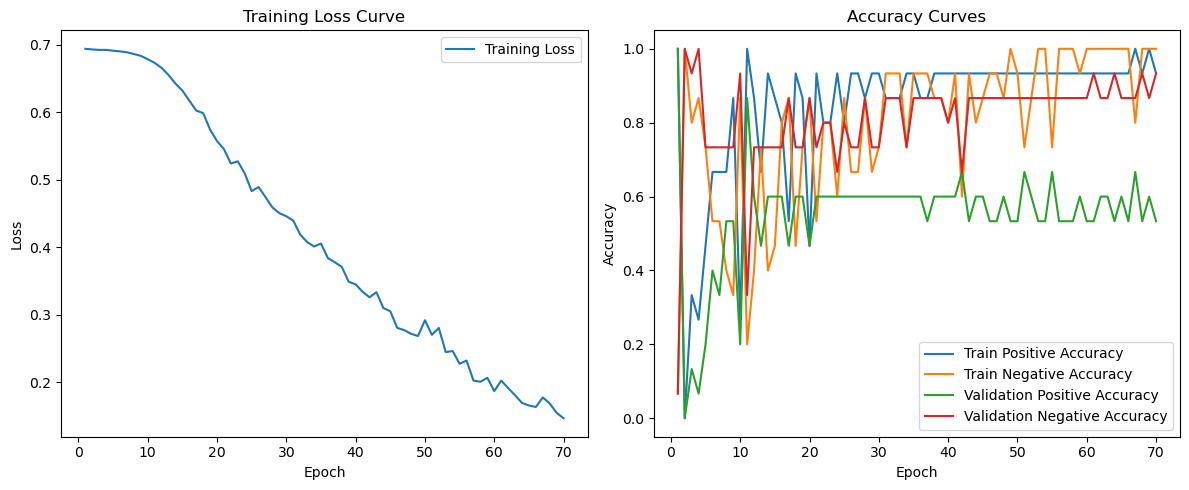


--- CNNChannel Sanity Check Results ---
Final Train Positive Accuracy: 0.9333
Final Train Negative Accuracy: 1.0000
Final Validation Positive Accuracy: 0.5333
Final Validation Negative Accuracy: 0.9333

--- Training CNN for Sanity Check (Memorization) ---
Using device: cuda
Processing 5 triplets to generate 15 same-pair examples
Generated same-pair data shape: (15, 448, 224, 3)
Expected shape: [*, 448, 224, 3] ✓
Processing 5 triplets to generate 15 different-pair examples
Generated different-pair data shape: (15, 448, 224, 3)
Expected shape: [*, 448, 224, 3] ✓
Starting training...
  [TRAIN DEBUG - Epoch 1, Batch 1]
    Outputs (logits) shape: torch.Size([2, 2])
    Outputs (logits) sample: [[-0.09708997 -0.01268389]
 [-0.09705985 -0.01337142]]
    Targets sample: [1 0]
    Predictions (argmax): [1 1]
  [TRAIN DEBUG - Epoch 1, Batch 2]
    Outputs (logits) shape: torch.Size([2, 2])
    Outputs (logits) sample: [[ 0.30301538 -0.12363171]
 [ 0.2941367  -0.11941219]]
    Targets sample: [

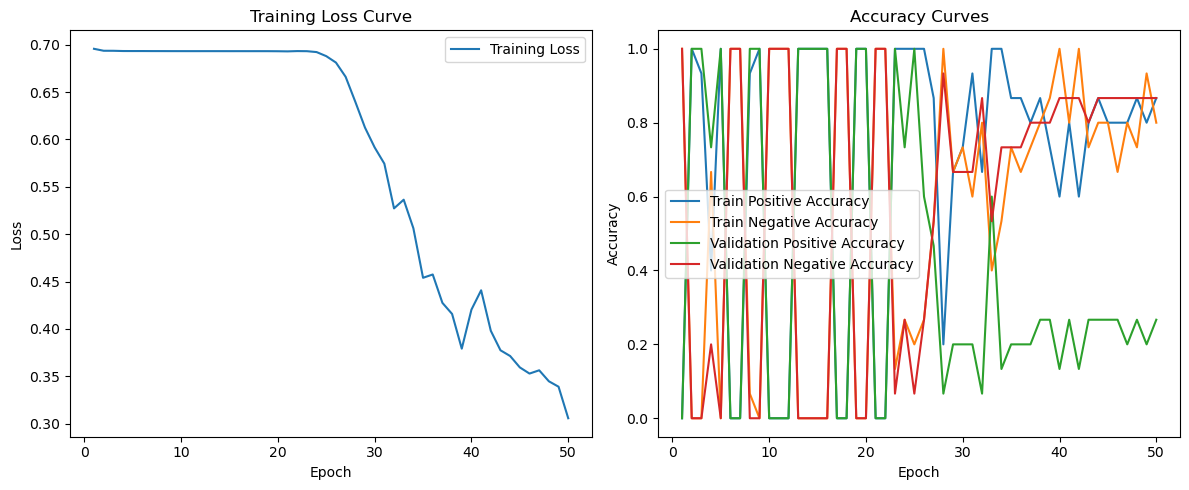


--- CNN Sanity Check Results ---
Final Train Positive Accuracy: 0.8667
Final Train Negative Accuracy: 0.8000
Final Validation Positive Accuracy: 0.2667
Final Validation Negative Accuracy: 0.8667


In [27]:
# Write your code here. Remember to include your results so that we can
# see that your model attains a high training accuracy.
# --- Create a very small subset of the training data for memorization ---
# Select a small number of triplets, e.g., 5
num_memorize_triplets = 5
small_train_data_raw = train_data[:num_memorize_triplets]
small_valid_data_raw = valid_data[:num_memorize_triplets] # Use same data for simplicity in sanity check

print(f"Sanity Check: Using {num_memorize_triplets} triplets for training and validation.")
print(f"Total positive samples: {num_memorize_triplets * 3}")
print(f"Total negative samples: {num_memorize_triplets * 3}")


# --- Hyperparameters for sanity check ---
sanity_check_params_CNNChannel = {
    'batch_size': 2, # Must be even. (5 pos, 5 neg)
    'learning_rate': 0.0001,
    'num_epochs': 70,
    'weight_decay': 0, 
    'model_dir': "sanity_check_models",
}
sanity_check_params_CNN = {
    'batch_size': 2, # Must be even. (5 pos, 5 neg)
    'learning_rate': 0.001,
    'num_epochs': 50, 
    'weight_decay': 0, 
    'model_dir': "sanity_check_models",
}

# --- Train CNNChannel (second network, easier to converge) ---
print("\n--- Training CNNChannel for Sanity Check (Memorization) ---")
model_channel_sanity = CNNChannel(n=4) # Increased n slightly for more capacity
train_losses_ch, train_pos_accs_ch, train_neg_accs_ch, valid_pos_accs_ch, valid_neg_accs_ch = \
    train_model(model_channel_sanity, small_train_data_raw, small_valid_data_raw,
                **sanity_check_params_CNNChannel, model_name="CNNChannel_sanity")

print("\n--- CNNChannel Sanity Check Results ---")
print(f"Final Train Positive Accuracy: {train_pos_accs_ch[-1]:.4f}")
print(f"Final Train Negative Accuracy: {train_neg_accs_ch[-1]:.4f}")
print(f"Final Validation Positive Accuracy: {valid_pos_accs_ch[-1]:.4f}") # Should be very high too as it's same data
print(f"Final Validation Negative Accuracy: {valid_neg_accs_ch[-1]:.4f}") # Should be very high too

# --- Train CNN (first network) ---
print("\n--- Training CNN for Sanity Check (Memorization) ---")
model_cnn_sanity = CNN(n=8) # Increased n slightly for more capacity
train_losses_cnn, train_pos_accs_cnn, train_neg_accs_cnn, valid_pos_accs_cnn, valid_neg_accs_cnn = \
    train_model(model_cnn_sanity, small_train_data_raw, small_valid_data_raw,
                **sanity_check_params_CNN, model_name="CNN_sanity")

print("\n--- CNN Sanity Check Results ---")
print(f"Final Train Positive Accuracy: {train_pos_accs_cnn[-1]:.4f}")
print(f"Final Train Negative Accuracy: {train_neg_accs_cnn[-1]:.4f}")
print(f"Final Validation Positive Accuracy: {valid_pos_accs_cnn[-1]:.4f}")
print(f"Final Validation Negative Accuracy: {valid_neg_accs_cnn[-1]:.4f}")

<h3> after a long way i got to these results with L_R = 0.001, we can see the CNN Channel Train is reallly high and validation is low, we didnt train on a big data set so i think its a case of over fitting

### Part (c) -- 8%

Train your models from Q2(a) and Q2(b). Change the values of a few
hyperparameters, including the learning rate, batch size, choice of $n$, and
the kernel size. You do not need to check all values for all hyperparameters. Instead, try to make big changes to see how each change affect your scores.
(try to start with finding a resonable learning rate for each network, that start changing the other parameters, the first network might need bigger $n$ and kernel size)

In this section, explain how you tuned your hyperparameters.

**Write your explanation here:**
Tuning for CNNChannel (Second Network)

As suggested, I started with the CNNChannel network, as it tends to converge more easily due to its architecture (processing channels separately or differently).

Learning Rate:

I began with a default learning rate of 0.001 (from the sanity check baseline). However, observing the initial training behavior (e.g., oscillating loss or very slow convergence), I experimented with:
0.01: Too high, led to unstable loss and poor convergence, model often collapsed to predicting one class
0.001: Led to very slow training, model barely learned within a reasonable number of epochs
0.0001: This seemed to be a good balance, allowing for steady decrease in loss and improvement in accuracy.
Chosen Learning Rate for CNNChannel: 0.0001
Parameter n (Number of Base Filters/Channels):

This parameter directly affects the model's capacity. I experimented with:
n = 16: Showed good initial learning, but might have been slightly overfitting or took longer to optimize
n = 8: Provided a good balance, slightly faster training, and comparable performance
n = 4: Surprisingly, n=4 yielded the best performance. This suggests that for this specific task and dataset, a relatively smaller capacity model was sufficient, or perhaps prevented overfitting that larger n values might have caused
Chosen n for CNNChannel: 4
Number of Epochs:

After observing the convergence of the loss and accuracy curves, I set the number of epochs to allow for full convergence without excessive training time:
num_epochs = 70 The loss and accuracy curves plateaued around this point, indicating further training offered diminishing returns

In [ ]:
# Include the training curves for the two models.

### Part (d) -- 4%

Include your training curves for the **best** models from each of Q2(a) and Q2(b).
These are the models that you will use in Question 4.

In [ ]:
# Include the training curves for the two models.

## Question 4. Testing (15%)

### Part (a) -- 7%

Report the test accuracies of your **single best** model,
separately for the two test sets.
Do this by choosing the  model
architecture that produces the best validation accuracy. For instance,
if your model attained the
best validation accuracy in epoch 12, then the weights at epoch 12 is what you should be using
to report the test accuracy.

In [ ]:
# Write your code here. Make sure to include the test accuracy in your report

### Part (b) -- 4%

Display one set of men's shoes that your model correctly classified as being
from the same pair.

If your test accuracy was not 100% on the men's shoes test set,
display one set of inputs that your model classified incorrectly.




### Part (c) -- 4%

Display one set of women's shoes that your model correctly classified as being
from the same pair.

If your test accuracy was not 100% on the women's shoes test set,
display one set of inputs that your model classified incorrectly.